# Data Audit — UCI Bank Marketing

01_eda.py — Data audit for the UCI Bank Marketing dataset.


Decision point for the whole project: the bank chooses whom to call
BEFORE the call happens. So for every column we ask: "would the bank
know this value at the moment it decides to dial the number?"

In [9]:
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

## 1. Load

In [10]:
df = pd.read_csv("data/bank-additional-full.csv", sep=";")

print("SHAPE")
print(df.shape)

print("\n")
print("DTYPES")
print(df.dtypes)

SHAPE
(41188, 21)


DTYPES
age                 int64
job                   str
marital               str
education             str
default               str
housing               str
loan                  str
contact               str
month                 str
day_of_week           str
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome              str
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                     str
dtype: object


## 2. Target balance

In [11]:
print("TARGET BALANCE (y)")
print(df["y"].value_counts())
print(df["y"].value_counts(normalize=True).round(4))
# This is a highly imbalanced problem (~11% positive class). That single
# fact rules out accuracy as a usable metric: predicting "no" for every
# row already scores ~89% accuracy while being useless to the bank.

TARGET BALANCE (y)
y
no     36548
yes     4640
Name: count, dtype: int64
y
no     0.8873
yes    0.1127
Name: proportion, dtype: float64


## 3. Categorical vs numeric fields

In [12]:
categorical_cols = df.select_dtypes(include="object").columns.tolist()
categorical_cols.remove("y")
numeric_cols = df.select_dtypes(include="number").columns.tolist()

print("CATEGORICAL COLUMNS")
print(categorical_cols)

print("\n")
print("NUMERIC COLUMNS")
print(numeric_cols)

CATEGORICAL COLUMNS
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


NUMERIC COLUMNS
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


C:\Users\daksh\AppData\Local\Temp\ipykernel_31612\4070335129.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns.tolist()


## 4. "unknown" values — how much of each categorical column is unknown?

In [13]:
print("'unknown' RATE PER CATEGORICAL COLUMN")
unknown_rates = (
    df[categorical_cols]
    .apply(lambda s: (s == "unknown").mean())
    .sort_values(ascending=False)
)
print(unknown_rates[unknown_rates > 0].round(4))
# default has a very high unknown rate — worth noting explicitly, since a
# column that's mostly "unknown" carries little information no matter how
# you encode it.

'unknown' RATE PER CATEGORICAL COLUMN
default      0.2087
education    0.0420
housing      0.0240
loan         0.0240
job          0.0080
marital      0.0019
dtype: float64


## 5. Special numeric codes

In [14]:
print("pdays SPECIAL CODE")
print("pdays == 999 (never previously contacted):",
      (df["pdays"] == 999).mean().round(4), "of rows")
print("pdays distribution for the remaining rows:")
print(df.loc[df["pdays"] != 999, "pdays"].describe())
# 999 is a sentinel, not a real day count. Leaving it untransformed and
# feeding it into a model that assumes continuous scale (e.g. LDA/QDA,
# logistic regression) would make "never contacted" look like
# "contacted 999 days ago" — wrong. This is a DECISION POINT: common
# treatments are (a) a binary "previously_contacted" flag + the real
# pdays for the rest, (b) leave as-is and accept the distortion, or
# (c) bucket pdays. Pick one and be ready to say why.

print("\n")
print("previous / poutcome cross-check")
print(pd.crosstab(df["previous"] == 0, df["poutcome"]))
# Confirms poutcome == 'nonexistent' lines up with previous == 0 and
# pdays == 999 — these three columns tell a consistent story about
# clients never contacted before.

pdays SPECIAL CODE
pdays == 999 (never previously contacted): 0.9632 of rows
pdays distribution for the remaining rows:
count    1515.000000
mean        6.014521
std         3.824906
min         0.000000
25%         3.000000
50%         6.000000
75%         7.000000
max        27.000000
Name: pdays, dtype: float64


previous / poutcome cross-check
poutcome  failure  nonexistent  success
previous                               
False        4252            0     1373
True            0        35563        0


## 6. Feature availability audit — THE key decision for this project

In [15]:
print("FEATURE AVAILABILITY AT DECISION POINT")

availability = {
    "age": "available (client attribute)",
    "job": "available (client attribute)",
    "marital": "available (client attribute)",
    "education": "available (client attribute)",
    "default": "available, but mostly 'unknown' — low info content",
    "housing": "available (client attribute)",
    "loan": "available (client attribute)",
    "contact": "available (contact channel is chosen before the call)",
    "month": "available (call is scheduled before it happens)",
    "day_of_week": "available (call is scheduled before it happens)",
    "duration": "NOT AVAILABLE — call duration is only known AFTER the "
                "call ends. UCI's own documentation flags this column as "
                "leakage for realistic prediction. MUST BE EXCLUDED.",
    "campaign": "available (running count of contacts so far this "
                "campaign for this client, known before dialling again)",
    "pdays": "available (outcome of a PAST campaign, known in advance)",
    "previous": "available (outcome of a PAST campaign, known in advance)",
    "poutcome": "available (outcome of a PAST campaign, known in advance)",
    "emp.var.rate": "available (published macro indicator) but reflects "
                    "TIME PERIOD more than the client — correlates with "
                    "which month the row is from",
    "cons.price.idx": "same caveat as emp.var.rate",
    "cons.conf.idx": "same caveat as emp.var.rate",
    "euribor3m": "same caveat as emp.var.rate",
    "nr.employed": "same caveat as emp.var.rate",
}
for col, note in availability.items():
    print(f"  {col:16s} -> {note}")

print(
    "\nEXCLUSION: 'duration' must be dropped before any supervised "
    "modelling — it is the single clearest leakage risk in this dataset.\n"
    "WATCH: the five economic-indicator columns are technically available "
    "pre-call, but because they vary strongly by calendar month (see section 7.8), "
    "they carry information about WHEN a row was collected, not just general macro "
    "conditions. With a temporal train/holdout split this can make the "
    "model partly a 'which time period is this' detector rather than a "
    "'which client is promising' detector. Keep them in but be ready to "
    "flag this as a limitation — don't silently ignore it."
)

FEATURE AVAILABILITY AT DECISION POINT
  age              -> available (client attribute)
  job              -> available (client attribute)
  marital          -> available (client attribute)
  education        -> available (client attribute)
  default          -> available, but mostly 'unknown' — low info content
  housing          -> available (client attribute)
  loan             -> available (client attribute)
  contact          -> available (contact channel is chosen before the call)
  month            -> available (call is scheduled before it happens)
  day_of_week      -> available (call is scheduled before it happens)
  duration         -> NOT AVAILABLE — call duration is only known AFTER the call ends. UCI's own documentation flags this column as leakage for realistic prediction. MUST BE EXCLUDED.
  campaign         -> available (running count of contacts so far this campaign for this client, known before dialling again)
  pdays            -> available (outcome of a PAST campa

## 7. Visual EDA

Each chart below answers one question. Charts whose information is already printed above (class balance, 'unknown' rates) are not repeated here.

**Target focus:** `y` is the dependent variable (subscribed or not). The question for every section is *what separates `y = yes` from `y = no`, and is that separation something the bank can use before dialling?*

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
BASE_RATE = (df["y"] == "yes").mean()
MONTH_ORDER = ["mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"]

def iqr_outlier_share(s):
    # Share of values beyond 1.5*IQR. Reported, never removed, so the charts show real tails.
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).mean()

def success_table(data, col, order=None):
    # Subscription rate per group with n and a 95% normal-approximation CI.
    # The CI matters for sparse groups (e.g. March/December) where a high rate can be noise.
    t = (data.assign(_yes=(data["y"] == "yes").astype(int))
             .groupby(col, observed=True)["_yes"]
             .agg(rate="mean", n="size").reset_index())
    t["ci"] = 1.96 * np.sqrt(t["rate"] * (1 - t["rate"]) / t["n"])
    if order is not None:
        t = t.set_index(col).reindex(order).reset_index()
    return t

### 7.1 Univariate: how skewed are the key numeric variables?

**Question:** Are the numeric variables roughly symmetric, or do a few extreme values dominate?
**Why a histogram:** it shows shape and tail length directly. Counts are on a log axis because `campaign` and `previous` have long tails that would otherwise be invisible.

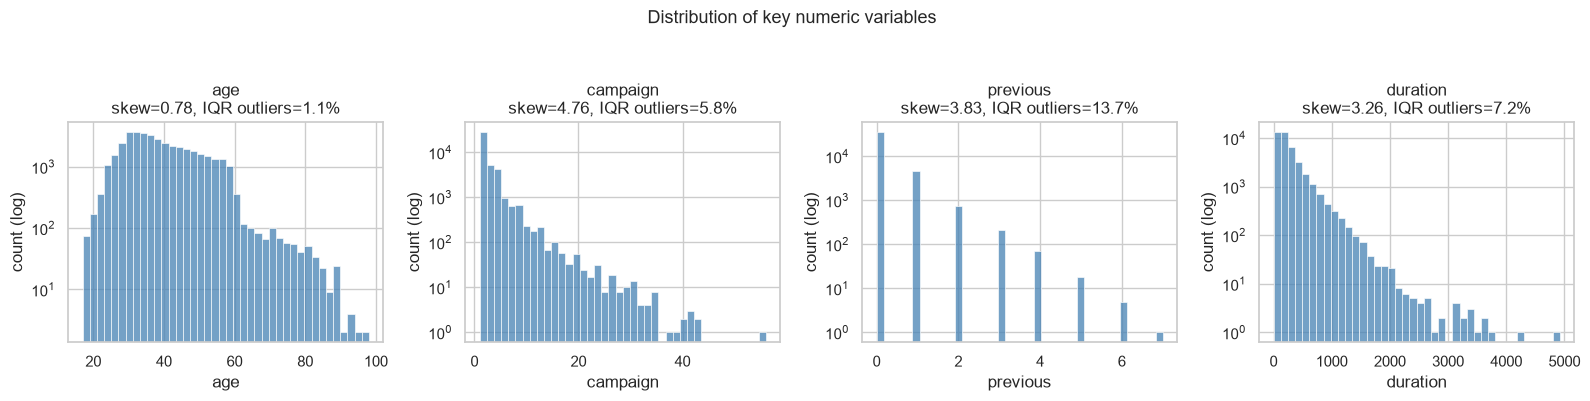

In [17]:
num_focus = ["age", "campaign", "previous", "duration"]

fig, axes = plt.subplots(1, len(num_focus), figsize=(16, 3.8))
for ax, c in zip(axes, num_focus):
    sns.histplot(df[c], bins=40, ax=ax, color="steelblue")
    ax.set_yscale("log")
    ax.set_title(f"{c}\nskew={df[c].skew():.2f}, IQR outliers={iqr_outlier_share(df[c]):.1%}")
    ax.set_xlabel(c)
    ax.set_ylabel("count (log)")
fig.suptitle("Distribution of key numeric variables", y=1.05, fontsize=13)
plt.tight_layout()
plt.show()

### 7.2 Numeric variables vs target

**Question:** Do numeric variables look different between clients who subscribed and those who did not?
**Why box plots:** they compare medians and spread across two groups and keep outliers visible.
**Note on `duration`:** it is plotted only to show the leakage. The call length is almost entirely separated by outcome, which is exactly why it is excluded from modelling (see section 6). Do not use this panel as a predictive finding.

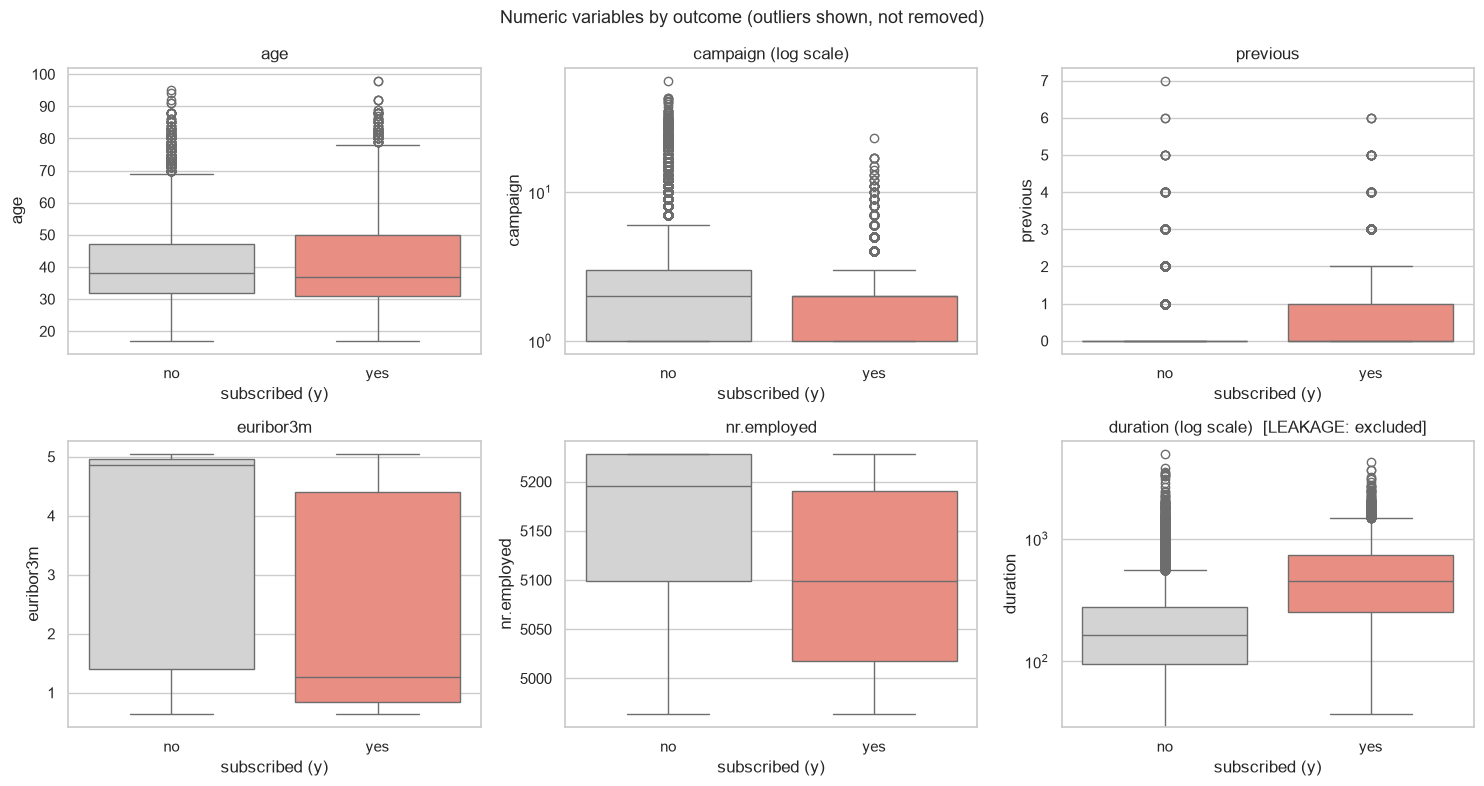

In [18]:
feats = ["age", "campaign", "previous", "euribor3m", "nr.employed", "duration"]
log_scale = {"campaign", "duration"}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, c in zip(axes.ravel(), feats):
    sns.boxplot(data=df, x="y", y=c, order=["no", "yes"], ax=ax,
                hue="y", palette={"no": "lightgrey", "yes": "salmon"}, legend=False)
    if c in log_scale:
        ax.set_yscale("log")
    title = c + (" (log scale)" if c in log_scale else "")
    if c == "duration":
        title += "  [LEAKAGE: excluded]"
    ax.set_title(title)
    ax.set_xlabel("subscribed (y)")
    ax.set_ylabel(c)
fig.suptitle("Numeric variables by outcome (outliers shown, not removed)", fontsize=13)
plt.tight_layout()
plt.show()

### 7.3 Job vs subscription rate

**Question:** Which occupations subscribe at above or below the overall rate of 11.3%?
**Why a sorted horizontal bar of rates, not counts:** counts reflect how many clients have each job; rates reflect how likely each job is to subscribe. The dashed line is the base rate. Sample size is printed on each bar so small groups are not over-read.

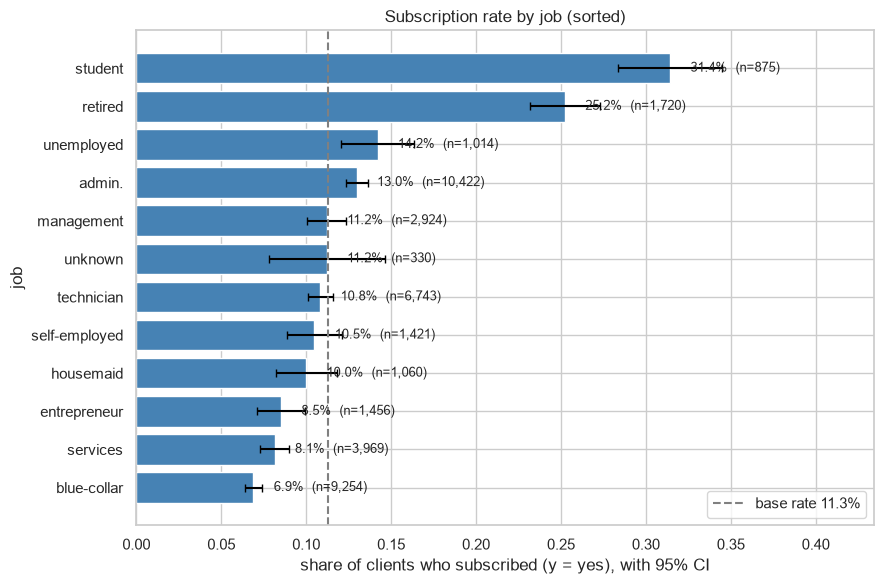

In [19]:
t = success_table(df, "job").sort_values("rate")

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(t["job"], t["rate"], color="steelblue")
ax.errorbar(t["rate"], t["job"], xerr=t["ci"], fmt="none", ecolor="black", capsize=3)
for i, (r, n) in enumerate(zip(t["rate"], t["n"])):
    ax.text(r + 0.012, i, f"{r:.1%}  (n={n:,})", va="center", fontsize=9)
ax.axvline(BASE_RATE, ls="--", color="grey", label=f"base rate {BASE_RATE:.1%}")
ax.set_xlim(0, t["rate"].max() + 0.12)
ax.set_xlabel("share of clients who subscribed (y = yes), with 95% CI")
ax.set_ylabel("job")
ax.set_title("Subscription rate by job (sorted)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


### 7.4 Previous campaign outcome vs subscription rate

**Question:** Do clients who subscribed in a past campaign subscribe again at a higher rate?
**Why this chart:** `poutcome` has the strongest association with `y` of any categorical field (Cramér's V = 0.32; see 7.10). The `nonexistent` group is most of the data, so its n is shown explicitly.


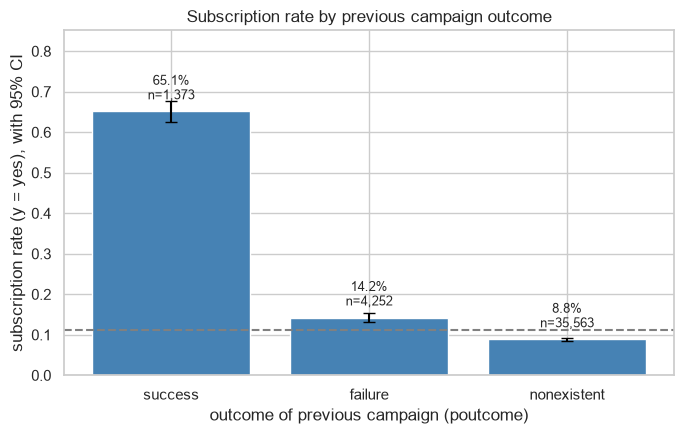

In [20]:
t = success_table(df, "poutcome").sort_values("rate", ascending=False)

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(t["poutcome"], t["rate"], color="steelblue")
ax.errorbar(t["poutcome"], t["rate"], yerr=t["ci"], fmt="none", ecolor="black", capsize=4)
for b, r, n in zip(bars, t["rate"], t["n"]):
    ax.text(b.get_x() + b.get_width() / 2, r + 0.03, f"{r:.1%}\nn={n:,}", ha="center", fontsize=9)
ax.axhline(BASE_RATE, ls="--", color="grey")
ax.set_ylim(0, min(1, t["rate"].max() + 0.2))
ax.set_ylabel("subscription rate (y = yes), with 95% CI")
ax.set_xlabel("outcome of previous campaign (poutcome)")
ax.set_title("Subscription rate by previous campaign outcome")
plt.tight_layout()
plt.show()

### 7.5 Age vs subscription rate: is the relationship linear?

**Question:** Is subscription rate a simple linear function of age, or is it nonlinear?
**Why binned rates:** a linear correlation with a binary target would hide a U-shape. Grouping by age band and plotting the rate shows the shape directly.

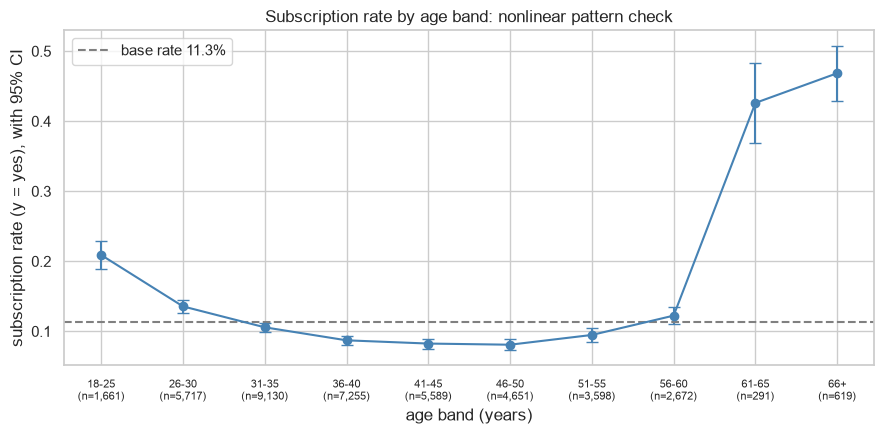

In [21]:
age_edges = [17, 25, 30, 35, 40, 45, 50, 55, 60, 65, 100]
age_labels = ["18-25", "26-30", "31-35", "36-40", "41-45", "46-50", "51-55", "56-60", "61-65", "66+"]
df["age_band"] = pd.cut(df["age"], bins=age_edges, labels=age_labels, right=True)

t = success_table(df, "age_band", order=age_labels)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.errorbar(range(len(t)), t["rate"], yerr=t["ci"], marker="o", capsize=4, color="steelblue")
ax.axhline(BASE_RATE, ls="--", color="grey", label=f"base rate {BASE_RATE:.1%}")
ax.set_xticks(range(len(t)))
ax.set_xticklabels([f"{a}\n(n={n:,})" for a, n in zip(t["age_band"], t["n"])], fontsize=8)
ax.set_ylabel("subscription rate (y = yes), with 95% CI")
ax.set_xlabel("age band (years)")
ax.set_title("Subscription rate by age band: nonlinear pattern check")
ax.legend()
plt.tight_layout()
plt.show()

### 7.6 Contact effort vs subscription rate

**Question:** Does calling a client more times in this campaign keep raising their chance of subscribing?
**Why buckets:** `campaign` has a very long tail (some clients were called dozens of times). Grouping into ordered buckets keeps the rate estimates stable where the counts are small.

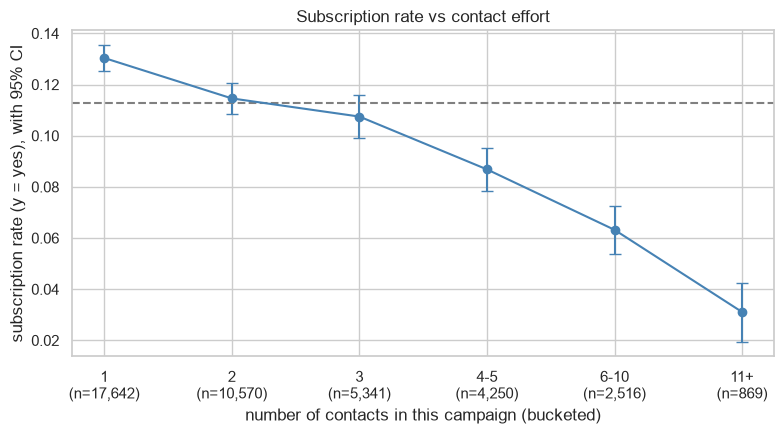

In [22]:
camp_labels = ["1", "2", "3", "4-5", "6-10", "11+"]
df["campaign_bucket"] = pd.cut(df["campaign"], bins=[0, 1, 2, 3, 5, 10, 100], labels=camp_labels)

t = success_table(df, "campaign_bucket", order=camp_labels)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.errorbar(range(len(t)), t["rate"], yerr=t["ci"], marker="o", capsize=4, color="steelblue")
ax.axhline(BASE_RATE, ls="--", color="grey")
ax.set_xticks(range(len(t)))
ax.set_xticklabels([f"{a}\n(n={n:,})" for a, n in zip(t["campaign_bucket"], t["n"])])
ax.set_xlabel("number of contacts in this campaign (bucketed)")
ax.set_ylabel("subscription rate (y = yes), with 95% CI")
ax.set_title("Subscription rate vs contact effort")
plt.tight_layout()
plt.show()

### 7.7 Seasonality: subscription rate by month

**Question:** Does the chance of subscribing vary by month the call was made?
**Why a line plot:** months are ordered, so a line shows the trend across the year. Points are annotated with n because March, September, October, and December have far fewer calls than the rest.

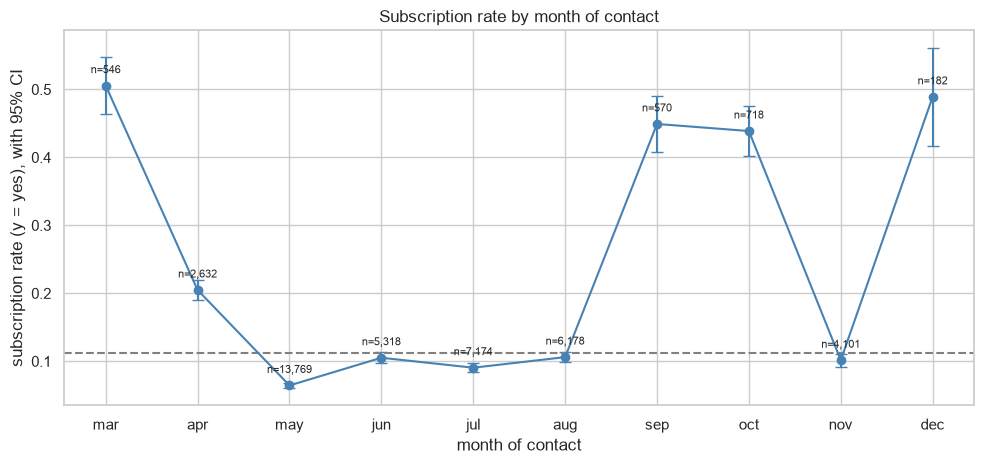

In [23]:
t = success_table(df, "month", order=MONTH_ORDER).dropna(subset=["rate"])

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.errorbar(t["month"], t["rate"], yerr=t["ci"], marker="o", capsize=4, color="steelblue")
for m, r, n in zip(t["month"], t["rate"], t["n"]):
    ax.annotate(f"n={n:,}", (m, r), textcoords="offset points", xytext=(0, 9), ha="center", fontsize=8)
ax.axhline(BASE_RATE, ls="--", color="grey")
ax.set_xlabel("month of contact")
ax.set_ylabel("subscription rate (y = yes), with 95% CI")
ax.set_title("Subscription rate by month of contact")
plt.tight_layout()
plt.show()

### 7.8 Do economic indicators just encode the calendar?

**Question:** Is `euribor3m` (one of the five macro indicators) mostly a proxy for *when* a call happened?
**Why this chart:** section 6 flagged this as a risk. If the boxes for each month barely overlap, the indicator carries calendar information, and a temporal split could make a model learn the period instead of the client.

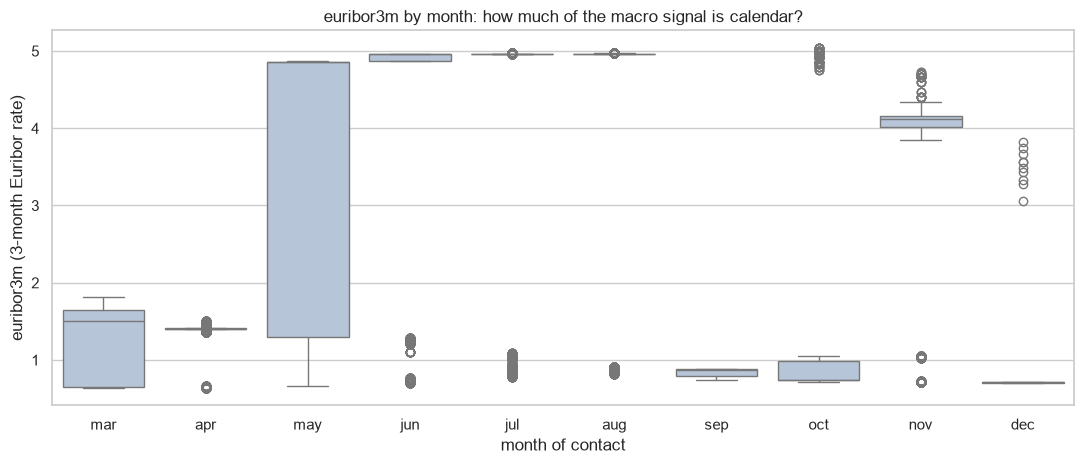

In [24]:
fig, ax = plt.subplots(figsize=(11, 4.8))
sub = df[df["month"].isin(MONTH_ORDER)]
sns.boxplot(data=sub, x="month", y="euribor3m", order=MONTH_ORDER, ax=ax, color="lightsteelblue")
ax.set_xlabel("month of contact")
ax.set_ylabel("euribor3m (3-month Euribor rate)")
ax.set_title("euribor3m by month: how much of the macro signal is calendar?")
plt.tight_layout()
plt.show()

### 7.9 Correlation among numeric features (collinearity check)

**Question:** Are the five macro indicators and the other numeric features redundant with each other?
**Why Spearman and a heatmap here:** this is a *feature-to-feature* check for redundancy, not a substitute for looking at the target. Spearman is used because the relationships are not assumed linear. `pdays = 999` is set to NaN so the sentinel code does not drive the correlations.

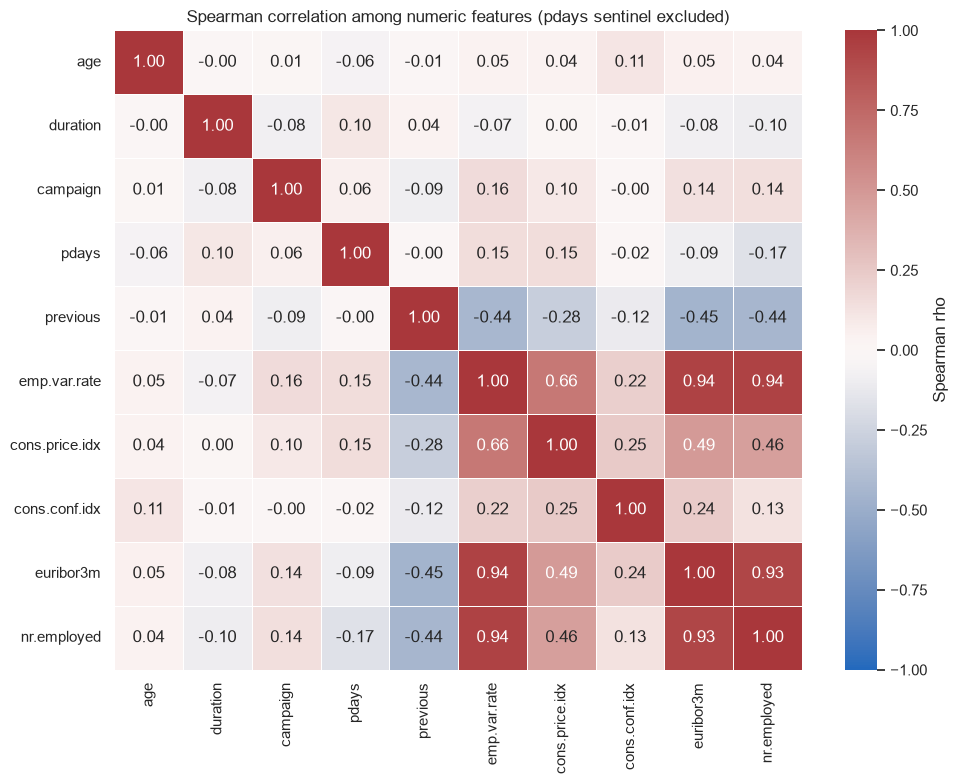

In [25]:
num_for_corr = df[numeric_cols].copy()
num_for_corr["pdays"] = num_for_corr["pdays"].replace(999, np.nan)
corr = num_for_corr.corr(method="spearman")

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-1, vmax=1,
            linewidths=0.5, cbar_kws={"label": "Spearman rho"}, ax=ax)
ax.set_title("Spearman correlation among numeric features (pdays sentinel excluded)")
plt.tight_layout()
plt.show()

### 7.10 Association strength and data-quality checks

**Question:** Which categorical fields are associated with `y`, and how strongly?
**Why Cramér's V:** a chi-square p-value is almost always tiny at this sample size (41k rows), so it does not rank fields. Cramér's V (0 = no association, 1 = perfect) does. The table also records exact duplicate rows, because they can inflate apparent evidence in any count-based chart.

In [26]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.values.sum()
    k = min(ct.shape) - 1
    return np.sqrt(chi2 / (n * k))

cat_for_v = ["poutcome", "month", "job", "contact", "default", "education",
             "marital", "day_of_week", "housing", "loan"]
v_table = pd.Series({c: cramers_v(df[c], df["y"]) for c in cat_for_v}).sort_values(ascending=False)
print("CRAMÉR'S V WITH y (categorical fields)")
print(v_table.round(3).to_string())

n_dup = df.duplicated().sum()
print(f"\nExact duplicate rows (all 21 columns identical): {n_dup} ({n_dup / len(df):.3%})")
print("Kept: no client identifier exists, so a repeat call cannot be distinguished from a duplicate entry.")

CRAMÉR'S V WITH y (categorical fields)
poutcome       0.320
month          0.274
job            0.153
contact        0.145
default        0.099
education      0.068
marital        0.055
day_of_week    0.025
housing        0.012
loan           0.005

Exact duplicate rows (all 21 columns identical): 12 (0.029%)
Kept: no client identifier exists, so a repeat call cannot be distinguished from a duplicate entry.


## 8. EDA Insights

Every number below comes from the run on the uploaded `bank-additional-full.csv` (41,188 rows, 11.27% subscribed). Associations are reported, not causes: none of these results show that a feature makes a client subscribe.

**Target and leakage**

- **`duration` is the dominant single feature (AUC 0.82 on its own).** Median call length is 449 seconds for subscribers and 164 for non-subscribers. This is a consequence of the call's outcome, not a predictor available before dialling, so it stays excluded (7.2).

**Strongest pre-call signals**

- **Previous outcome (`poutcome`) is the strongest categorical association (V = 0.32).** Clients whose previous campaign succeeded subscribe at 65.1% (n = 1,373), versus 14.2% after a failure and 8.8% for clients never contacted before (n = 35,563) (7.4).
- **`pdays` carries the same signal.** Clients with a previous contact subscribe at 63.8%, against 9.3% for the rest. Because `pdays != 999` and `poutcome != nonexistent` are the same rows, keep one representation, not both, to avoid double-counting.
- **Job separates clients clearly (V = 0.15).** Students (31.4%) and retirees (25.2%) subscribe far above the base rate; blue-collar workers are lowest at 6.9% (n = 9,254). Chi-square p < 0.001 (7.3).

**Non-linear and diminishing-return patterns**

- **Age is U-shaped, not linear (7.5).** Subscription is 20.9% at age 25 and under, falls to about 8% for ages 41 to 50, then rises to 42.6% for ages 61 to 65 and 46.8% for 66 and over. Those two oldest bands total only 910 clients, so their intervals are wide. A linear age term would miss this shape.
- **More contacts in this campaign lower the rate (7.6).** Subscription falls from 13.0% at one contact to 11.5%, 10.7%, 8.7%, 6.3%, and 3.1% at 11 or more. The most-called clients may simply be less interested, so this is an association.

**Month and the macro indicators: a confounded pair**

- **Month is strongly associated with `y` (V = 0.27), but in an unexpected way (7.7).** March (50.5%), September (44.9%), October (43.9%), and December (48.9%) all have high rates on small samples (182 to 718 calls). May, the largest month with 13,769 calls, is at 6.4%.
- **The macro indicators mostly encode the calendar (7.8, 7.9).** `euribor3m` and `nr.employed` each explain a large share of variance by calendar month (η² = 0.33 and 0.42). `emp.var.rate`, `euribor3m`, and `nr.employed` are correlated at Spearman 0.93 to 0.94. Their individual AUCs (about 0.25 to 0.28) are strong, but they may be measuring the period rather than the client.
- **Implication:** the high-rate months in 7.7 are months with very low Euribor, so month and the macro indicators cannot be cleanly separated in this data. Any model that includes both should be evaluated with this in mind, and a temporal holdout will largely test the period.

**Data quality**

- **Class imbalance (11.3% positive):** accuracy is misleading here. Predicting "no" always scores about 89%. Use precision/recall, PR-AUC, or lift in the top decile of calls.
- **`pdays = 999` covers 96.3% of rows.** Only 1,515 clients have a real value. Keep the sentinel handled explicitly (flag plus real value), as section 5 describes.
- **`poutcome`, `previous`, and `pdays` agree:** `poutcome = nonexistent` matches `previous = 0` and `pdays = 999` exactly.
- **Skewed, with long tails:** `campaign` (skew 4.8, max 56), `previous` (skew 3.8, 13.7% outside the IQR fences), and `duration` (skew 3.3). `age` is mild (skew 0.8). Outliers are kept in all charts; none were removed.
- **Sparse categories:** `default` has only 3 `yes` values and 20.9% `unknown`. `default` should not be used as a feature.
- **12 exact duplicate rows** (identical in all 21 columns). With no client identifier, these cannot be confirmed as duplicates or repeated calls. They are kept and flagged, and make up 0.03% of the data, so they do not change any conclusion.

**Correction to the original audit text**

The section 6 note said the rows are date-ordered. The file has no date column, only `month` and `day_of_week`, so row order cannot be verified. The note now references section 7.8 instead.

## 9. Summary for modelling

- **Visualizations added:** 9 charts (section 7), plus a Cramér's V table (7.10).
- **Use with confidence:** `poutcome` (or the `pdays` flag, not both), `job`, `contact` (V = 0.15, check cellular vs telephone as a categorical), `age` (non-linear: use bins or a spline), `campaign` (monotonic decline, consider log or buckets).
- **Exclude:** `duration` (leakage).
- **Use with caution:** `month` and the five macro indicators, which largely share one calendar signal. Evaluate with and without them.
- **Weak, not worth modelling on their own:** `day_of_week` (V = 0.03), `housing` (0.01), `loan` (0.005).
- **Not added, and why:** target balance and 'unknown' rate bars (exact numbers are printed above); a full pairplot (too many features to read); pie charts (no simple part-to-whole question); a day-of-week chart (V = 0.03, so there is no pattern to show).